# Метод градиентного спуска

На прошлом занятии мы познакомились с понятием производной и нашли минимум
функции с одной переменной. При этом, мы отказались от использования второй
переменной сдвига.
$$ y = w \cdot x $$
Сегодня мы научимся находить минимум функции с двумя переменными $w$ и $b$
и построим полноценную модель простой линейной регрессии (Simple Linear
Regression).
$$ y = w \cdot x + b $$
Для этого мы напишем алгоритм, который называется **методом градиентного
спуска** (gradient descent method). Однако перед этим возьмем более простую
функцию и на ее примере изучим, как работает этот метод.
##Градиент и метод градиентного спуска
###Функция нескольких переменных

Рассмотрим вот такую функцию потерь.
$$ f(w_1, w_2) = w_1^2 + w_2^2 $$
График этой функции можно представить в трехмерном пространстве, где по осям
$w_1$ и $w_2$ отложены веса исходной модели, а по оси $f(w_1, w_2)$ — уровень
потерь при заданных весах.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

Посмотрим на график этой функции.

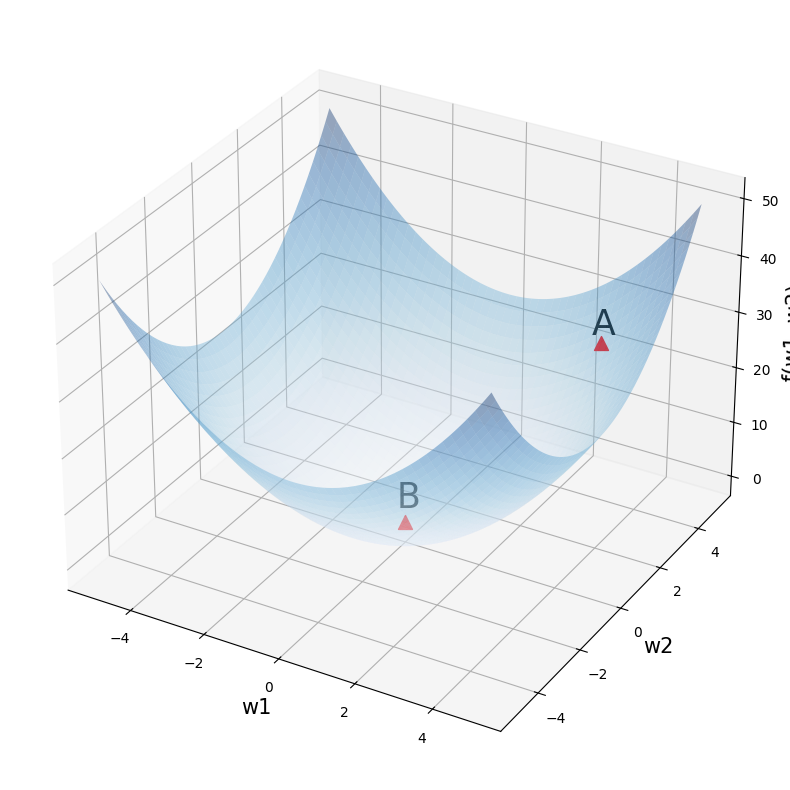

In [ ]:
# установим размер графика
fig = plt.figure(figsize = (12,10))

# создадим последовательность из 1000 точек в интервале от -5 до 5
# для осей w1 и w2
w1 = np.linspace(-5, 5, 1000)
w2 = np.linspace(-5, 5, 1000)

# создадим координатную плоскость из осей w1 и w2
w1, w2 = np.meshgrid(w1, w2)

# пропишем функцию
f = w1 ** 2 + w2 ** 2

# создадим трехмерное пространство
ax = fig.add_subplot(projection = '3d')

# выведем график функции, alpha задает прозрачность
ax.plot_surface(w1, w2, f, alpha = 0.4, cmap = 'Blues')

# выведем точку A с координатами (3, 4, 25) и подпись к ней
ax.scatter(3, 4, 25, c = 'red', marker = '^', s = 100)
ax.text(3, 3.5, 28, 'A', size = 25)

# аналогично выведем точку B с координатами (0, 0, 0)
ax.scatter(0, 0, 0, c = 'red', marker = '^', s = 100)
ax.text(0, -0.4, 4, 'B', size = 25)

# укажем подписи к осям
ax.set_xlabel('w1', fontsize = 15)
ax.set_ylabel('w2', fontsize = 15)
ax.set_zlabel('f(w1, w2)', fontsize = 15)

# выведем результат
plt.show()

Предположим, мы начали с весов в **точке A** с координатами (3, 4, 25). Как нам
спуститься в минимум функции в **точке B** (0, 0, 0)? Просто двигаться в
направлении, обратном производной, мы не можем. Ведь единственной
производной, которая бы описывала все изменения нашей функции, просто не
существует.

Все дело в том, что если смотреть на нашу функцию «сверху» (то есть на *график изолиний*  или линий уровня, contour lines), то в каждой точке у нас теперь два
направления, по оси $w_1$ и по оси $w_2.$


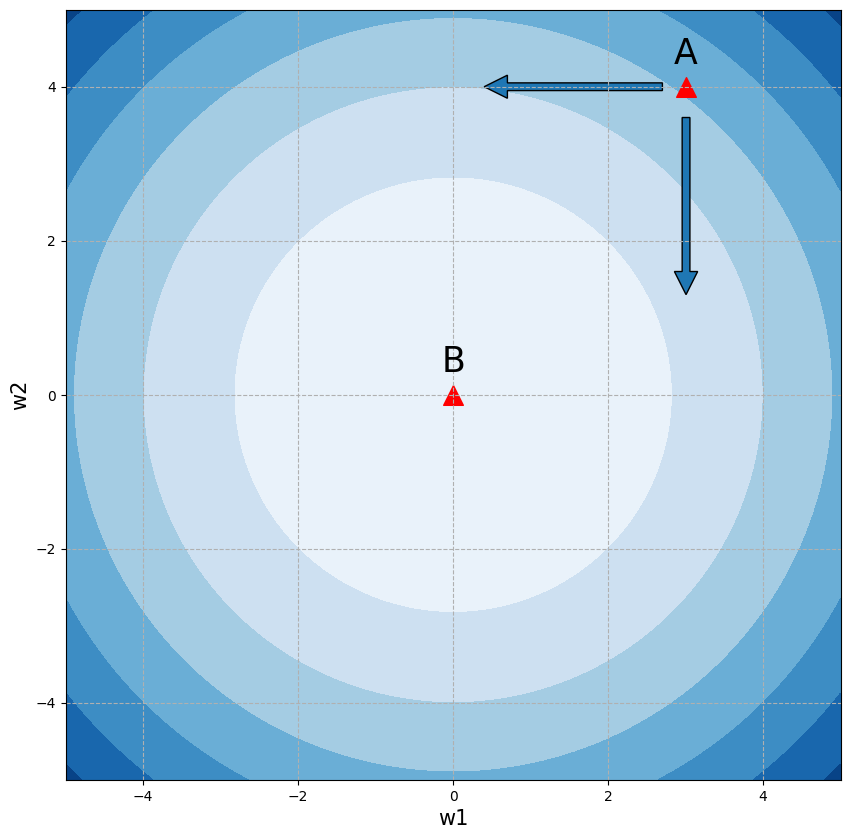

In [ ]:
# установим размер графика
fig, ax = plt.subplots(figsize = (10,10))

# создадим последовательность из 100 точек в интервале от -5 до 5
# для осей w1 и w2
w1 = np.linspace(-5.0, 5.0, 100)
w2 = np.linspace(-5.0, 5.0, 100)

# создадим координатную плоскость из осей w1 и w2
w1, w2 = np.meshgrid(w1, w2)

# пропишем функцию
C = w1 ** 2 + w2 ** 2

# построим изолинии (линии уровня)
plt.contourf(w1, w2, C, cmap = 'Blues')

# выведем точку А с координатами на плоскости (3, 4)
ax.scatter(3, 4, c = 'red', marker = '^', s = 200)
ax.text(2.85, 4.3, 'A', size = 25)

# и точку B с координатами (0, 0)
ax.scatter(0, 0, c = 'red', marker = '^', s = 200)
ax.text(-0.15, 0.3, 'B', size = 25)

# укажем подписи к осям
ax.set_xlabel('w1', fontsize = 15)
ax.set_ylabel('w2', fontsize = 15)

# а также стрелки направления изменений вдоль w1 и w2
ax.arrow(2.7, 4, -2, 0, width = 0.1, head_length = 0.3)
ax.arrow(3.005, 3.6, 0, -2, width = 0.1, head_length = 0.3)

# создадим сетку в виде прерывистой черты
plt.grid(linestyle = '--')

# выведем результат
plt.show()

Как понять, куда нам двигаться?

### Частная производная

Если «заморозить» одну из переменных (то есть представить, что это константа),
пусть это будет $w_2,$ мы можем найти производную по первой переменной
$w_1.$
$$ f_{w_1} = \frac{\partial f}{\partial w_1} = 2w_1 $$
Такая производная называется **частной** (partial derivative), потому что она
описывает изменение только в первой переменной $w_1.$

Графически, мы как бы убираем переменную $w_2$ (получается сечение,
представленное параболой) и ищем производную функции, в которой есть только
переменная $w_1.$

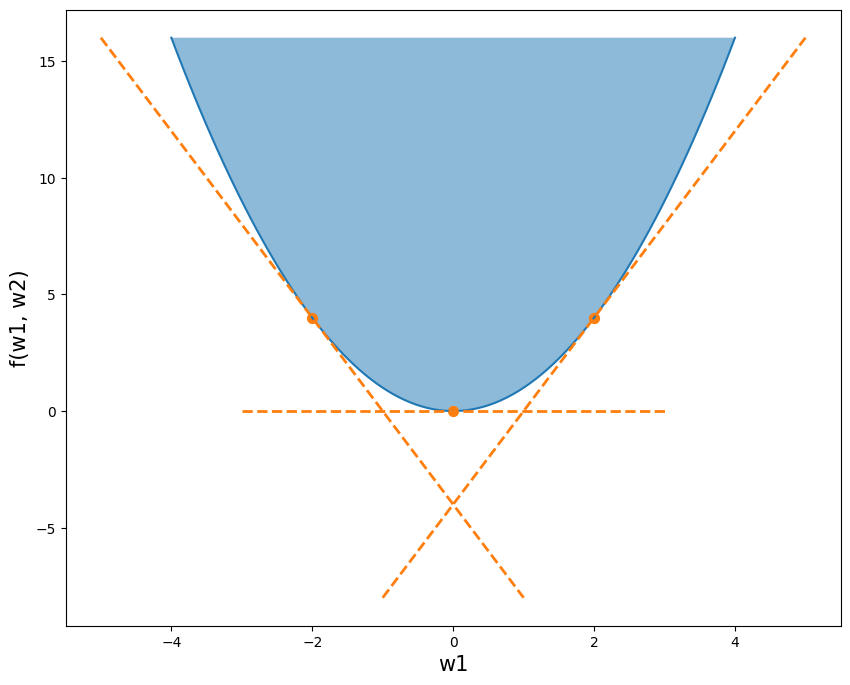

In [ ]:
# зададим размер графика в дюймах
plt.figure(figsize = (10, 8))

# объявим функцию параболы
def f(x):
  return x ** 2

# объявим ее производную
def der(x):
  return 2 * x

# пропишем уравнение через point-slope form
# y - y1 = m * (x - x1) --> y = m * (x - x1) + y1
def line(x, x1, y1):
  return der(x1) * (x - x1) + y1

# создадим последовательность координат x для параболы
x = np.linspace(-4, 4, 100)

# построим график параболы
plt.plot(x, f(x))

# и заполним ее по умолчанию синим цветом с прозрачностью 0,5
plt.fill_between(x, f(x), 16, alpha = 0.5)

# в цикле пройдемся по точкам -2, 0, 2 на оси х
for x1 in range(-2, 3, 2):

  # рассчитаем соответствующие им координаты y
  y1 = f(x1)

  # определим пространство по оси x для касательных линий
  xrange = np.linspace(x1 - 3, x1 + 3, 9)

  # построим касательные линии
  plt.plot(xrange, line(xrange, x1, y1), 'C1--', linewidth = 2)

  # и точки соприкосновения с графиком параболы
  plt.scatter(x1, y1, color = 'C1', s = 50)

# укажем подписи к осям
plt.xlabel('w1', fontsize = 15)
plt.ylabel('f(w1, w2)', fontsize = 15)

# выведем результат
plt.show()

Точно таким же образом мы поступаем со второй переменной $w_2.$ Мы
замораживаем первую переменную $w_1$ и вычисляем частную производную.
$$ f_{w_2} = \frac{\partial f}{\partial w_2} = 2w_2 $$
Теперь, взяв точку на плоскости $(w_1, w_2),$ мы будем точно знать скорость
изменения функции $f(w_1, w_2)$ в этой точке в каждом из направлений.
Например, возьмем ту же точку A с координатами $w_1 = 3, w_2 = 4,$ скорость
изменения функции в первом измерении будет равна $2 \times 3 = 6,$ во втором $2
\times 4 = 8.$
###Нотация анализа
Вы вероятно заметили, что мы использовали две нотации (записи) частной
производной. С первой мы уже знакомы по предыдущему занятию, это нотация
Лагранжа.
$$ f(w) \rightarrow f'(w) $$
Вторую нотацию, нотацию Лейбница, удобнее использовать для записи частных
производных.
$$ f(w_1, w_2) \rightarrow \frac{\partial f}{\partial w_1}, \frac{\partial f}{\partial w_2}
$$
Она позволяет сразу увидеть, по какой переменной происходит
дифференцирование.

Напомню, что запись формул (и, в частности, производной) в текстовых
ячейках блокнотов с помощью LaTeX мы изучили, когда говорили про Jupyter (Colab)
Notebook.
###Взятие частных производных
Пошагово рассмотрим, как мы пришли к результату $(2w_1, 2w_2).$ Вначале
найдем производную по первой переменой $w_1.$ Вторую переменную, $w_2,$ мы
будем считать константой, то есть некоторым числом.
$$ \frac{\partial f}{\partial w_1} (w_1^2 + w_2^2) $$
Первое, что бросается в глаза, это то, что у нас производная суммы, а она, как
известно, равна сумме производных.
$$ \frac{\partial f}{\partial w_1} (w_1^2 + w_2^2) = \frac{\partial f}{\partial w_1}
(w_1^2) + \frac{\partial f}{\partial w_1} (w_2^2) $$
Производную первого слагаемого мы найдем по правилу производной степенной
функции. Второе слагаемое мы решили считать константой, а производная константы равна нулю.
$$ \frac{\partial f}{\partial w_1} (w_1^2) + \frac{\partial f}{\partial w_1} (w_2^2) =
2w_1 + 0 = 2w_1 $$
Частная производная по второй переменной находится аналогично.

###Использование SymPy

**Функцию diff()** библиотеки SymPy можно также использовать для взятия частных
производных. Вначале импортируем функцию **diff()** и символы $x$ и $y$ (мы их
используем вместо $w_1$ и $w_2$).


In [ ]:
# импортируем фукцию diff() и
from sympy import diff

# превратим x и y в символы
from sympy.abc import x, y

Напишем функцию, которую хотим дифференцировать.

In [ ]:
# напишем функцию, которую хотим дифференцировать
f = x ** 2 + y ** 2

После этого мы можем находить частные производные, передав в **diff()** функцию
для дифференцирования, а затем либо первую, либо вторую переменную.

In [ ]:
# найдем частную производную по первой переменной
diff(f, x)

2*x

In [ ]:
# найдем частную производную по второй переменной
diff(f, y)

2*y

###Градиент
**Градиент** (gradient) есть не что иное, как совокупность частных производных по каждой из независимых переменных. Его можно назвать «полной производной».

Он обозначается через греческую букву «набла», $\nabla$ или оператор
Гамильтона.
$$ \nabla f(w_1, w_2) = \begin{bmatrix} \frac{\partial f}{\partial w_1} \\ \frac{\partial
f}{\partial w_1} \end{bmatrix} = \begin{bmatrix} 2w_1 \\ 2w_2 \end{bmatrix} $$
Еще раз посмотрим, чему равен градиент в точке (3, 4), но уже в новой записи.
$$ \nabla f(3, 4) = \begin{bmatrix} 2 \cdot 3 \\ 2 \cdot 4 \end{bmatrix} =
\begin{bmatrix} 6 \\ 8 \end{bmatrix} $$
Как вы видите, такая функция на входе принимает два числа, а на выходе выдает
вектор, также состоящий из двух чисел. В этом случае говорят о вектор-функции
(vector-valued function).

### Метод градиентного спуска
Градиент, который мы только что нашли, показывает **направление скорейшего
подъема** (возрастания) функции. Нам же, если мы хотим найти минимум
функции, нужно двигаться вниз в направлении, обратном направлению градиента
(еще говорят про направление антиградиента, negative gradient).

Вектор антиградиента на графике

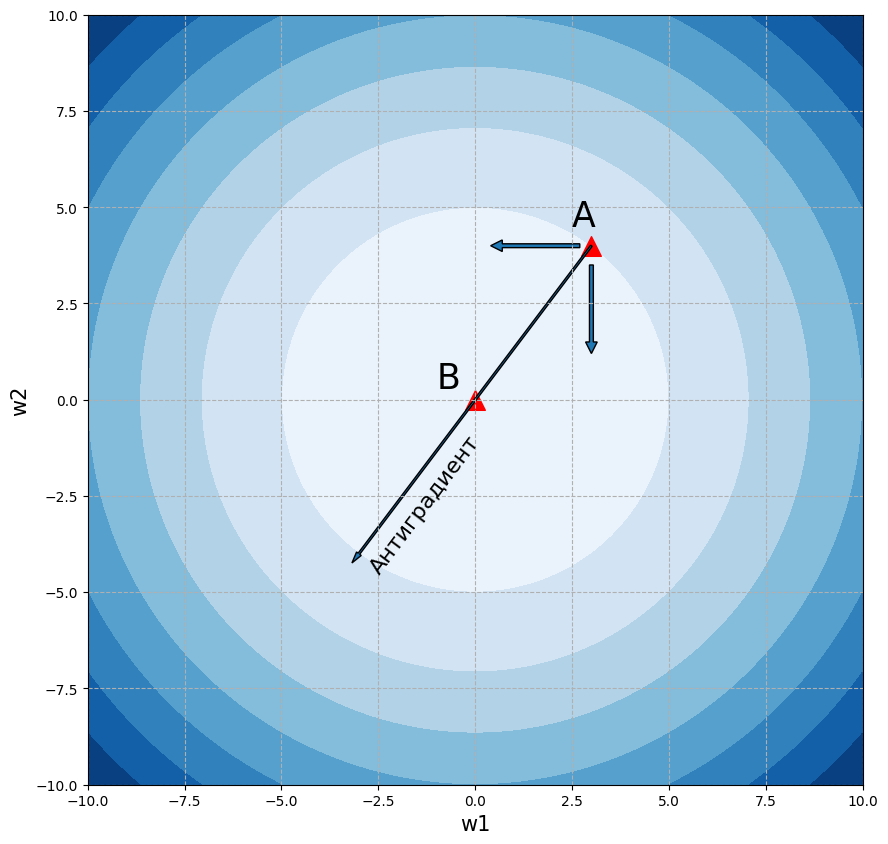

In [ ]:
# установим размер графика
fig, ax = plt.subplots(figsize = (10,10))

# создадим последовательность из 100 точек в интервале от -10 до 10
# для осей w1 и w2
w1 = np.linspace(-10.0, 10.0, 100)
w2 = np.linspace(-10.0, 10.0, 100)

# создадим координатную плоскость из осей w1 и w2
w1, w2 = np.meshgrid(w1, w2)

# пропишем функцию
C = w1 ** 2 + w2 ** 2

# построим изолинии (линии уровня)
plt.contourf(w1, w2, C, cmap = 'Blues')

# выведем точку А с координатами на плоскости (3, 4)
ax.scatter(3, 4, c = 'red', marker = '^', s = 200)
ax.text(2.5, 4.5, 'A', size = 25)

# и точку B с координатами (0, 0)
ax.scatter(0, 0, c = 'red', marker = '^', s = 200)
ax.text(-1, 0.3, 'B', size = 25)

# укажем подписи к осям
ax.set_xlabel('w1', fontsize = 15)
ax.set_ylabel('w2', fontsize = 15)

# а также стрелки направления изменений вдоль w1 и w2
ax.arrow(2.7, 4, -2, 0, width = 0.1, head_length = 0.3)
ax.arrow(3, 3.5, 0, -2, width = 0.1, head_length = 0.3)

# выведем вектор антиградиента с направлением (-6, -8)
ax.arrow(3, 4, -6, -8, width = 0.05, head_length = 0.3)
ax.text(-2.8, -4.5, 'Антиградиент', rotation = 53, size = 16)

# создадим сетку в виде прерывистой черты
plt.grid(linestyle = '--')

# выведем результат
plt.show()

Если мы сдвинемся на $-6$ по оси $w_1$ и на $-8$ по оси $w_2,$ то обязательно
пройдем через минимум функции. Теперь мы готовы дать определение.

**Метод градиентного спуска** — это способ нахождения локального
минимума функции в процессе движения в направлении антиградиента.

При этом, если мы сдвинемся на всю величину градиента, то «перескочим» через
минимум. Именно поэтому нам нужен коэффициент скорости обучения (learning
rate).

Воспользуемся этим методом для нахождения минимума приведенной выше
функции. Другими словами, проделаем путь из точки А в точку B.

###Метод градиентного спуска на Питоне
Вначале объявим необходимые функции.

In [ ]:
# пропишем функцию потерь
def objective(w1, w2):
    return w1 ** 2 + w2 ** 2

# а также производную по первой
def partial_1(w1):
    return 2.0 * w1

# и второй переменной
def partial_2(w2):
  return 2.0 * w2

Зададим исходные параметры модели.

In [ ]:
# пропишем изначальные веса
w1, w2 = 3, 4

# количество итераций
iter = 100

# и скорость обучения
learning_rate = 0.05

Теперь создадим списки для учета обновления весов $w_1$ и $w_2$ и изменения
уровня ошибки.

In [ ]:
# создадим списки для учета весов и уровня ошибки
w1_list, w2_list, l_list = [], [], []

Найдем минимум функции потерь.

In [ ]:
# в цикле с заданным количеством итераций
for i in range(iter):

  # будем добавлять текущие веса в соответствующие списки
  w1_list.append(w1)
  w2_list.append(w2)

  # и рассчитывать и добавлять в список текущий уровень ошибки
  l_list.append(objective(w1, w2))

  # также рассчитаем значение частных производных при текущих весах
  par_1 = partial_1(w1)
  par_2 = partial_2(w2)

  # будем обновлять веса в направлении,
  # обратном направлению градиента, умноженному на скорость обучения
  w1 = w1 - learning_rate * par_1
  w2 = w2 - learning_rate * par_2

# выведем итоговые веса модели и значение функции потерь
w1, w2, objective(w1, w2)

(7.968419666276241e-05, 0.00010624559555034984, 1.7637697771638315e-08)

Как мы видим, уже после ста итераций, как веса модели, так и уровень ошибки
приблизились к нулю.

Разумеется, более сложные функции потерь потребуют большего количества
итераций и более тонкой настройки коэффициента скорости обучения.

Остается посмотреть на графике, какой путь проделал наш алгоритм градиентного
спуска.

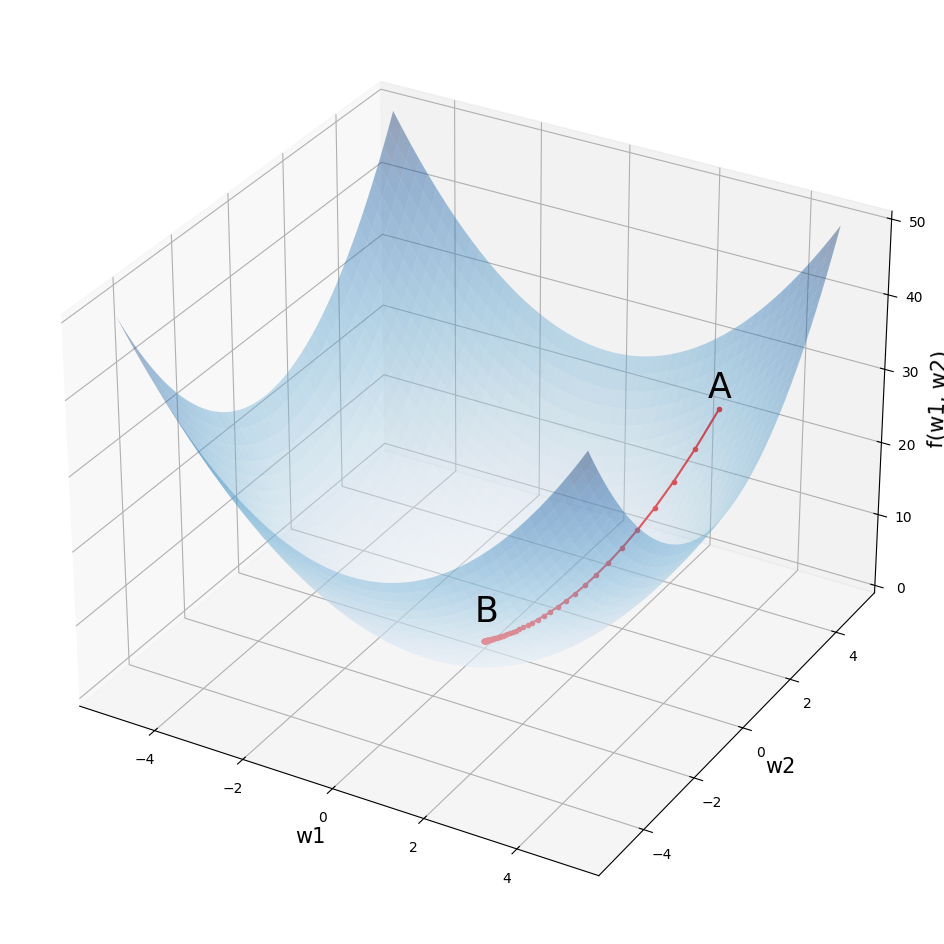

In [ ]:
fig = plt.figure(figsize = (14,12))

w1 = np.linspace(-5, 5, 1000)
w2 = np.linspace(-5, 5, 1000)

w1, w2 = np.meshgrid(w1, w2)

f = w1 ** 2 + w2 ** 2

ax = fig.add_subplot(projection = '3d')

ax.plot_surface(w1, w2, f, alpha = 0.4, cmap = 'Blues')

ax.text(3, 3.5, 28, 'A', size = 25)
ax.text(0, -0.4, 4, 'B', size = 25)

ax.set_xlabel('w1', fontsize = 15)
ax.set_ylabel('w2', fontsize = 15)
ax.set_zlabel('f(w1, w2)', fontsize = 15)

# выведем путь алгоритма оптимизации
ax.plot(w1_list, w2_list, l_list, '.-', c = 'red')

plt.show()

###Промежуточные выводы
Давайте еще раз проговорим основные идеи пройденного материала:
1. градиент показывает скорость изменения многомерной функции по каждому
из измерений (по каждой из переменных);
2. если «заморозить» все независимые переменные кроме одной и сделать срез,
то наклон касательной к кривой среза будет значением частной производной
по этому измерению; и самое важное для нас
3. градиент показывает направление скорейшего подъёма (возрастания)
функции; двигаясь в обратном направлении, мы придем к минимуму функции.

## Простая линейная регрессия

А теперь давайте с нуля напишем нашу первую модель машинного обучения. Мы
наконец-то приобрели для этого все необходимые знания. Наша модель будет
по-прежнему иметь только один признак, но при этом будет учитываться не только
наклон, но и сдвиг прямой.
$$ \hat{y} = w \cdot x + b $$
###Данные и постановка задачи
Сегодня мы возьмем хорошо известные нам данные роста и обхвата шеи и сразу
преобразуем их в массив Numpy.

In [ ]:
# возьмем уже известные нам данные роста и обхвата шеи
X = np.array([1.48, 1.49, 1.49, 1.50, 1.51, 1.52, 1.52, 1.53, 1.53, 1.54, 1.55, 1.56, 1.57, 1.57, 1.58, 1.58, 1.59, 1.60, 1.61, 1.62, 1.63, 1.64, 1.65, 1.65, 1.66, 1.67, 1.67, 1.68, 1.68,  1.69, 1.70, 1.70, 1.71, 1.71, 1.71, 1.74, 1.75, 1.76, 1.77, 1.77, 1.78])
y = np.array([29.1, 30.0, 30.1, 30.2, 30.4, 30.6, 30.8, 30.9, 31.0, 30.6, 30.7, 30.9, 31.0, 31.2, 31.3, 32.0, 31.4, 31.9, 32.4, 32.8, 32.8, 33.3, 33.6, 33.0, 33.9, 33.8, 35.0, 34.5, 34.7, 34.6, 34.2, 34.8, 35.5, 36.0, 36.2, 36.3, 36.6, 36.8, 36.8, 37.0, 38.5])

Выведем эти данные на графике с помощью диаграммы рассеяния или точечной
диаграммы.

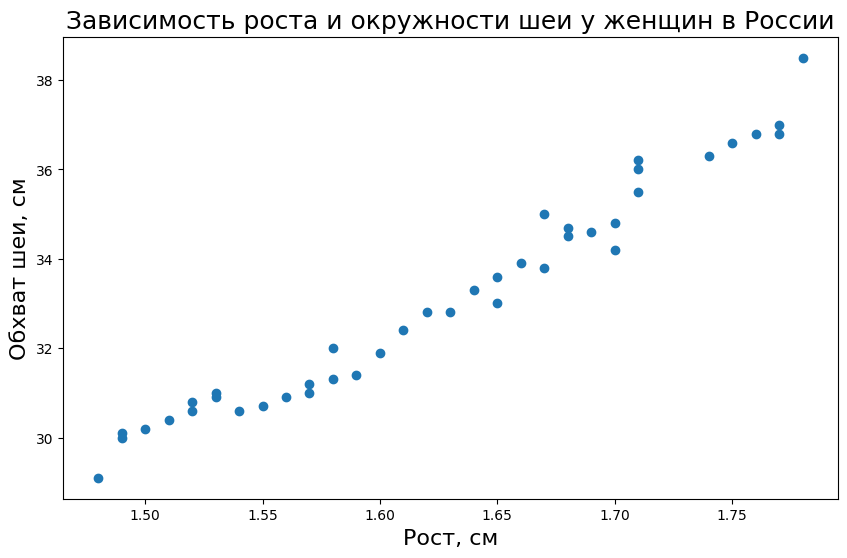

In [ ]:
# построим точечную диаграмму
plt.figure(figsize = (10,6))
plt.scatter(X, y)

# добавим подписи
plt.xlabel('Рост, см', fontsize = 16)
plt.ylabel('Обхват шеи, см', fontsize = 16)
plt.title('Зависимость роста и окружности шеи у женщин в России', fontsize = 18)

plt.show()

Как мы помним, нашей задачей является минимизация средней суммы квадрата
расстояний между данными и линией регрессии.

![](https://drive.google.com/uc?export=view&id=1Ul-fy16gPsF2aviP4OoUuVAfhxjOkhNi)

Также приведем формулу.
$$ MSE = \frac {1}{n} \sum^{n}_{i=1} (y_i-\hat{y}_i)^2 $$
###Решение методом наименьшних квадратов
Прежде чем использовать алгоритм градиентного спуска, найдем аналитическое
решение с помощью **метода наименьших квадратов** (МНК, least squares
method). Для уравнения с одной независимой переменной, используется следующая
формула.
$$ w = \frac {\sum_{i = 1}^{n} (x_i-\bar{x})(y_i-\bar{y})} {\sum_{i = 1}^{n} (x_i-
\bar{x})^2} $$
$$ b = \bar{y}-w\bar{x} $$
Приведем доказательство. Заметим, что простая линейная регрессия для $n$
независимых одинаково распределенных наблюдений определяется как
$$ y = b + wx + \varepsilon, \epsilon_i \sim \mathcal{N}(0, \sigma^2), i = 1,\ldots,n, $$
где $\varepsilon$ — ошибка или отклонение фактических данных от прогнозных,
следующая согласно допущению модели линейной регрессии нормальному
распределению со средним значением 0 и дисперсией или шумом $\sigma^2.$
Сумма квадратов отклонений (residual sum of squares, RSS), таким образом,
определяется как
$$ RSS(b,w) = \sum_{i=1}^n \varepsilon_i^2 = \sum_{i=1}^n (y_i — b — w x_i)^2 $$
Найдем производные относительно параметров модели $w$ и $b.$
$$ \begin{split} \frac{\mathrm{d}\mathrm{RSS}(b,o)}{\mathrm{d}b} &=
\sum_{i=1}^n 2 (y_i-b-w x_i) (-1) \\ &= -2 \sum_{i=1}^n (y_i-b-w x_i) \\
\frac{\mathrm{d}\mathrm{RSS}(b,w)}{\mathrm{d}w} &= \sum_{i=1}^n 2 (y_i-b-w
x_i) (-x_i) \\ &= -2 \sum_{i=1}^n (x_i y_i-b x_i-w x_i^2) \end{split} $$
Приравняем производные к нулю.
$$ \begin{split} 0 &= -2 \sum_{i=1}^n (y_i-\hat{b}-\hat{w} x_i) \\ 0 &= -2
\sum_{i=1}^n (x_i y_i-\hat{b} x_i — \hat{w} x_i^2) \end{split} $$
Преобразуем уравнения.
$$ \begin{split} \hat{w} \sum_{i=1}^n x_i + \hat{b} \cdot n &= \sum_{i=1}^n y_i \\
\hat{w} \sum_{i=1}^n x_i^2 + \hat{b} \sum_{i=1}^n x_i &= \sum_{i=1}^n x_i y_i
\end{split} $$
Решим первое уравнение относительно параметра $b.$
$$ \begin{split} \hat{b} &= \frac{1}{n} \sum_{i=1}^n y_i-\hat{w} \cdot \frac{1}{n}
\sum_{i=1}^n x_i \\ &= \bar{y}-\hat{w} \bar{x} \end{split} $$
Выразим $w$ из второго уравнения.
$$ \begin{split} \hat{w} \sum_{i=1}^n x_i^2 + \hat{b} \sum_{i=1}^n x_i &=
\sum_{i=1}^n x_i y_i \\ \hat{w} \sum_{i=1}^n x_i^2 + \left( \bar{y}-\hat{w} \bar{x}
\right) \sum_{i=1}^n x_i &= \sum_{i=1}^n x_i y_i \\ \hat{w} \left( \sum_{i=1}^n x_i^2-
\bar{x} \sum_{i=1}^n x_i \right) &= \sum_{i=1}^n x_i y_i-\bar{y} \sum_{i=1}^n x_i \\
\hat{w} &= \frac{\sum_{i=1}^n x_i y_i-\bar{y} \sum_{i=1}^n x_i}{\sum_{i=1}^n
x_i^2-\bar{x} \sum_{i=1}^n x_i} \end{split} $$
Преобразуем числитель
$$ \begin{split} \sum_{i=1}^n x_i y_i-\bar{y} \sum_{i=1}^n x_i &= \sum_{i=1}^n x_i
y_i-n \bar{x} \bar{y} \\ &= \sum_{i=1}^n x_i y_i-n \bar{x} \bar{y}-n \bar{x} \bar{y} +
n \bar{x} \bar{y} \\ &= \sum_{i=1}^n x_i y_i-\bar{y} \sum_{i=1}^n x_i-\bar{x}
\sum_{i=1}^n y_i + \sum_{i=1}^n \bar{x} \bar{y} \\ &= \sum_{i=1}^n \left( x_i y_i-x_i
\bar{y}-\bar{x} y_i + \bar{x} \bar{y} \right) \\ &= \sum_{i=1}^n (x_i-\bar{x}) (y_i-
\bar{y}) \end{split} $$
и знаменатель
$$ \begin{split} \sum_{i=1}^n x_i^2-\bar{x} \sum_{i=1}^n x_i &= \sum_{i=1}^n x_i^2-
n \bar{x}^2 \\ &= \sum_{i=1}^n x_i^2-2 n \bar{x} \bar{x} + n \bar{x}^2 \\ &= \sum_{i=1}^n x_i^2-2 \bar{x} \sum_{i=1}^n x_i + \sum_{i=1}^n \bar{x}^2 \\ &=
\sum_{i=1}^n \left( x_i^2-2 \bar{x} x_i + \bar{x}^2 \right) \\ &= \sum_{i=1}^n (x_i-
\bar{x})^2 \end{split} $$
Таким образом,
$$ \begin{split} \hat{w} &= \frac{\sum_{i=1}^n x_i y_i-\bar{y} \sum_{i=1}^n x_i}
{\sum_{i=1}^n x_i^2-\bar{x} \sum_{i=1}^n x_i} \\ &= \frac{\sum_{i=1}^n (x_i-
\bar{x}) (y_i-\bar{y})}{\sum_{i=1}^n (x_i-\bar{x})^2} \end{split} $$
Более того,
$$ \begin{split} \hat{w} &= \frac{\frac{1}{n-1} \sum_{i=1}^n (x_i-\bar{x}) (y_i-
\bar{y})}{\frac{1}{n-1} \sum_{i=1}^n (x_i-\bar{x})^2} \\ &= \frac{s_{xy}}{s_x^2}\;,
\end{split} $$
где $s_{xy}$ — ковариация $x$ и $y,$ а $s_x^2$ — дисперсия $x.$

###Собственная модель

Давайте вычислим наклон и сдвиг прямой с помощью этой формулы на Питоне.

In [ ]:
# найдем среднее значение X и y
X_mean = np.mean(X)
y_mean = np.mean(y)

# объявим переменные для числителя и знаменателя
numerator, denominator = 0, 0

# в цикле пройдемся по данным
for i in range(len(X)):

    # вычислим значения числителя и знаменателя по формуле выше
    numerator += (X[i] - X_mean) * (y[i] - y_mean)
    denominator += (X[i] - X_mean) ** 2

# найдем наклон и сдвиг
w = numerator / denominator
b = y_mean - w * X_mean

w, b

(np.float64(26.861812005569753), np.float64(-10.570936299787313))

Также давайте реализуем этот алгоритм с помощью векторизованного кода.

In [ ]:
# то же решение, но с векторизованным кодом
w = np.sum((X - X_mean) * (y - y_mean)) / np.sum((X - X_mean) ** 2)
b = y_mean - w * X_mean

w, b

(np.float64(26.861812005569757), np.float64(-10.57093629978732))

#### Модель LinearRegression библиотеки sklearn
Надо сказать, что модель LinearRegression, которую мы использовали на вводном
занятии по оптимизации и затем на занятии по линейной регрессии применяет
именно МНК для минимизации MSE.

Давайте еще раз применим класс LinearRegression, чтобы убедиться в получении
одинаковых результатов.

In [ ]:
# из набора линейных моделей библиотеки sklearn импортируем линейную регрессию
from sklearn.linear_model import LinearRegression

# создадим объект этого класса и запишем в переменную model
model = LinearRegression()

# обучим модель (для X используем двумерный массив)
model.fit(X.reshape(-1, 1), y)

# выведем коэффициенты
model.coef_, model.intercept_

(array([26.86181201]), np.float64(-10.570936299787334))

Как вы видите, результаты одинаковы. Теперь сделаем прогноз и рассчитаем
среднеквадратическую ошибку.

In [ ]:
# сделаем прогноз
y_pred_least_squares = model.predict(X.reshape(-1, 1))

# импортируем модуль метрик
from sklearn import metrics

# выведем среднеквадратическую ошибку (MSE)
metrics.mean_squared_error(y, y_pred_least_squares)

0.2273395626677337

Позднее мы сравним этот результат с аналогичным показателем алгоритма
градиентного спуска.

### МНК и метод градиентного спуска
Одна из причин использования алгоритма градиентного спуска вместо МНК
заключается в том, что этот алгоритм менее требователен к вычислительным
ресурсам при большом объеме (количестве наблюдений) и размерности (количестве
признаков) данных.
Кроме того, метод градиентного спуска может применяться не только в задачах
линейной регрессии, но и в других алгоритмах (например, в логистической
регрессии, SVM или нейросетях).
##Решение методом градиентного спуска
###Модель линейной регрессии и функция потерь
Начнем с того, что объявим функцию линейной модели.

In [ ]:
def regression(X, w, b):
  return w * X + b

Теперь давайте немного модифицируем функцию потерь и найдем половину
среднеквадратической ошибки (half MSE). Обозначим нашу функцию буквой $J.$
$$ J_{MSE} = \frac{1}{2n} \sum_{i=1}^{n} (y_i-(wx_i+b))^2 $$
Число два в знаменателе удачно сократится с двойкой, полученной при
дифференцировании степенной функции. При этом точка минимума функции не изменится.

In [ ]:
def objective(X, y, w, b, n):
  return np.sum((y - regression(X, w, b)) ** 2) / (2 * n)

Дополнительно замечу, что использование именно среднеквадратической, то есть
усредненной на количество наблюдений, ошибки (MSE) вместо «простой» суммы
квадратов отклонений (Sum of Squared Errors, SSE)
$$ J_{SSE} = \sum_{i=1} (y_i-(wx_i+b))^2 $$
может быть предпочтительнее, поскольку позволяет сравнивать результаты модели
на выборках разных размеров.

$$\require{cancel}$$
#### Частные производные функции потерь
Найдем частные производные этой функции. Их будет две: одна по наклону $(w),$
вторая по сдвигу $(b).$ Начнем с наклона.
$$ \frac{\partial J}{\partial w} \left( \frac{1}{2n} \sum_{i=1}^{n} (y_i-
(wx_i+b))^2 \right) $$
**Шаг 1.** Вынесем число $\frac{1}{2n}$ за скобку по правилу умножения на число. В
данном случае $n$, то есть количество наблюдений, превратится в число, как
только мы применим формулу к набору данных.
$$ \frac{\partial J}{\partial w} = \frac{1}{2n} \frac{\partial J}{\partial w}
\sum_{i=1}^{n} \left( (y_i-(wx_i+b))^2 \right) $$
**Шаг 2.** Теперь давайте для удобства перепишем выражение в векторизованной
форме. Теперь $x$ и $y$ будут не отдельными числами, а векторами.
$$ \frac{\partial J}{\partial w} = \frac{1}{2n} \frac{\partial J}{\partial w} \left( (y-
(wx+b)) ^2 \right) $$
**Шаг 3.** Перед нами композиция из двух функций. Применим правило прозводной
сложной функции.
$$ \frac{\partial J}{\partial w} = \frac{1}{2n} \cdot 2(y-(wx+b)) \cdot \frac{\partial J}
{\partial w} (y-(wx+b)) $$
**Шаг 4.** К внутренней функции мы можем применить правило суммы и разности
производных.
$$ \frac{1}{2n} \cdot 2(y-(wx+b)) \cdot (0-(x+0)) $$
Замечу, что при дифференцировании внутренней функции, $y$ превратился в ноль,
потому что это константа. Одновременно переменную $b$ мы «заморозили» и
также решили считать константой.
**Шаг 5.** Упростим выражение.
$$ \frac{\partial J}{\partial w} = \frac{1}{\cancel{2}n} \cdot \cancel{2}-x(y-(wx+b)) =
\frac{1}{n} \cdot -x(y-(wx+b)) $$
Аналогично найдем частную производную по **сдвигу**.
$$ \frac{\partial J}{\partial b} = \frac{1}{n} \cdot -(y-(wx+b)) $$
Здесь стоит лишь уточнить, что при нахождении производной внутренней функции
мы «заморозили» переменную $w.$
$$ \frac{\partial J}{\partial b} \left( (y-(wx+b)) \right) = 0-(0+1)$$
В невекторизованной форме производные выглядят следующим образом.
$$ \frac{\partial J}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} -x_i(y_i-(wx_i+b)) $$
$$ \frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} -(y_i-(wx_i+b)) $$
Поменяв слагаемые в скобках местами и умножив на $-1$, частные производные можно записать и так.
$$ \frac{\partial J}{\partial w} = \frac{1}{n} \sum_{i=1}^{n} ((wx_i+b)-y_i) \cdot
x_i $$
$$ \frac{\partial J}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} ((wx_i+b)-y_i) $$
Пропишем эти функции на Питоне.

In [ ]:
def partial_w(X, y, w, b, n):
  return np.sum(-X * (y - (w * X + b))) / n

def partial_b(X, y, w, b, n):
  return np.sum(-(y - (w * X + b))) / n

#### Алгоритм градиентного спуска
Создадим функцию, которая будет на входе принимать данные, количество
итераций и коэффициент скорости обучения, а на выходе выдавать веса модели и
уровень ошибки.

In [ ]:
# передадим функции данные, количество итераций и скорость обучения
def gradient_descent(X, y, iter, learning_rate):

  # зададим изначальные веса
  w, b = 0, 0
  # и количество наблюдений
  n = len(X)

  # создадим списки для записи весов модели и уровня ошибки
  w_list, b_list, l_list = [], [], []

  # в цикле с заданным количеством итераций
  for i in range(iter):

    # добавим в списки текущие веса
    w_list.append(w)
    b_list.append(b)
    # и уровень ошибки
    l_list.append(objective(X, y, w, b, n))

    # рассчитаем текущее значение частных производных
    par_1 = partial_w(X, y, w, b, n)
    par_2 = partial_b(X, y, w, b, n)

    # обновим веса в направлении антиградиента
    w = w - learning_rate * par_1
    b = b - learning_rate * par_2

  # выведем списки с уровнями ошибки и весами
  return w_list, b_list, l_list

#### Обучение модели
Применим написанную выше функцию для обучения модели. Используем
следующие гиперпараметры модели:
* количество итераций — 200 000;
* коэффициент скорости обучения — 0,01.

Напомню, что гиперпараметр — это параметр, который мы задаем до
обучения модели.

In [ ]:
# распакуем результат работы функции в три переменные
w_list, b_list, l_list = gradient_descent(X, y, iter = 200000, learning_rate = 0.01)

# и выведем последние достигнутые значения уровня ошибки и весов
print(w_list[-1], b_list[-1], l_list[-1])

26.69174625207742 -10.293843835595947 0.11378239841533976


#### Прогноз
В целом, как мы видим, веса модели очень близки к результату, найденному с
помощью метода наименьших квадратов. Теперь сделаем прогноз.

In [ ]:
# сделаем прогноз, используя наиболее оптимальные веса
y_pred_gd = regression(X, w_list[-1], b_list[-1])
y_pred_gd[:5]

array([29.20994062, 29.47685808, 29.47685808, 29.74377554, 30.01069301])

#### Посмотрим на результат на графике.

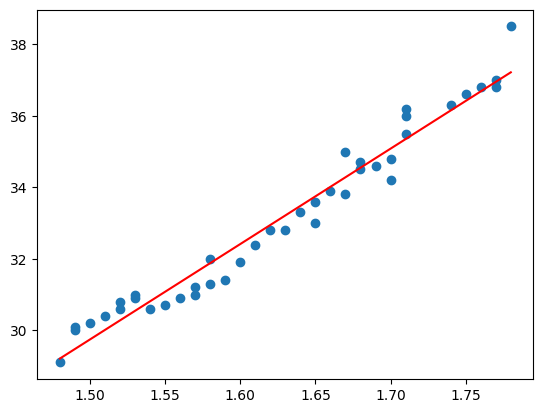

In [ ]:
# выведем прямую регрессии
plt.scatter(X, y)
plt.plot(X, y_pred_gd, 'r')
plt.show()

Кроме того, мы можем посмотреть на то, как снижался уровень ошибки с каждой
последующей итерацией.

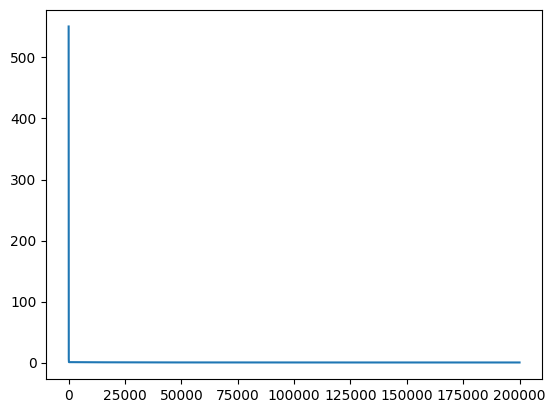

In [ ]:
# посмотрим на уровень ошибки
plt.plot(l_list);

Как мы видим, в первые итерации уровень ошибки снижался настолько
стремительно, что последующие изменения практически незаметны. Давайте
попробуем отбросить первые 150 наблюдений.

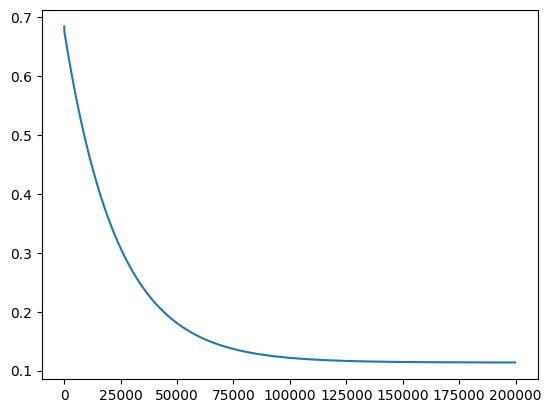

In [ ]:
# отбросим первые 150 наблюдений
plt.plot(l_list[150:]);

И все же кажется, что после 150000 итераций ошибка перестает снижаться и можно
было бы обойтись меньшим количеством шагов. На самом деле это не так.

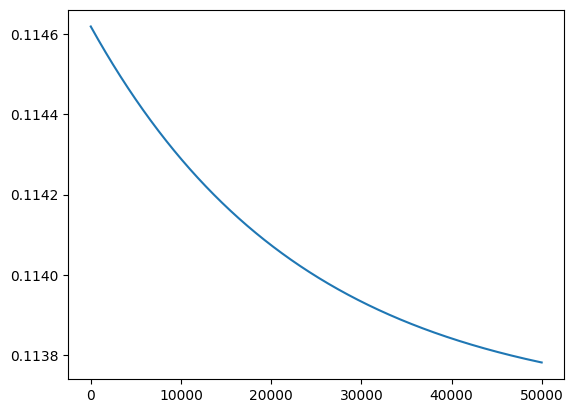

In [ ]:
# отбросим первые 150 000 наблюдений
plt.plot(l_list[150000:]);

В целом подбор количества итераций и длины шага (коэффициента скорости
обучения) довольно существенно влияют на качество обучения. Ближе к концу
занятия мы рассмотрим этот момент более подробно.

#### Оценка качества модели
Оценим качество модели с помощью встроенной в sklearn метрики.

In [ ]:
# рассчитаем MSE
metrics.mean_squared_error(y, y_pred_gd)

0.2275647968306795

Результат очень близок к тому, который мы получили, используя МНК.
### Визуализация шагов алгоритма оптимизации
Мы также как и раньше, можем посмотреть на путь, пройденный алгоритмом
оптимизации.

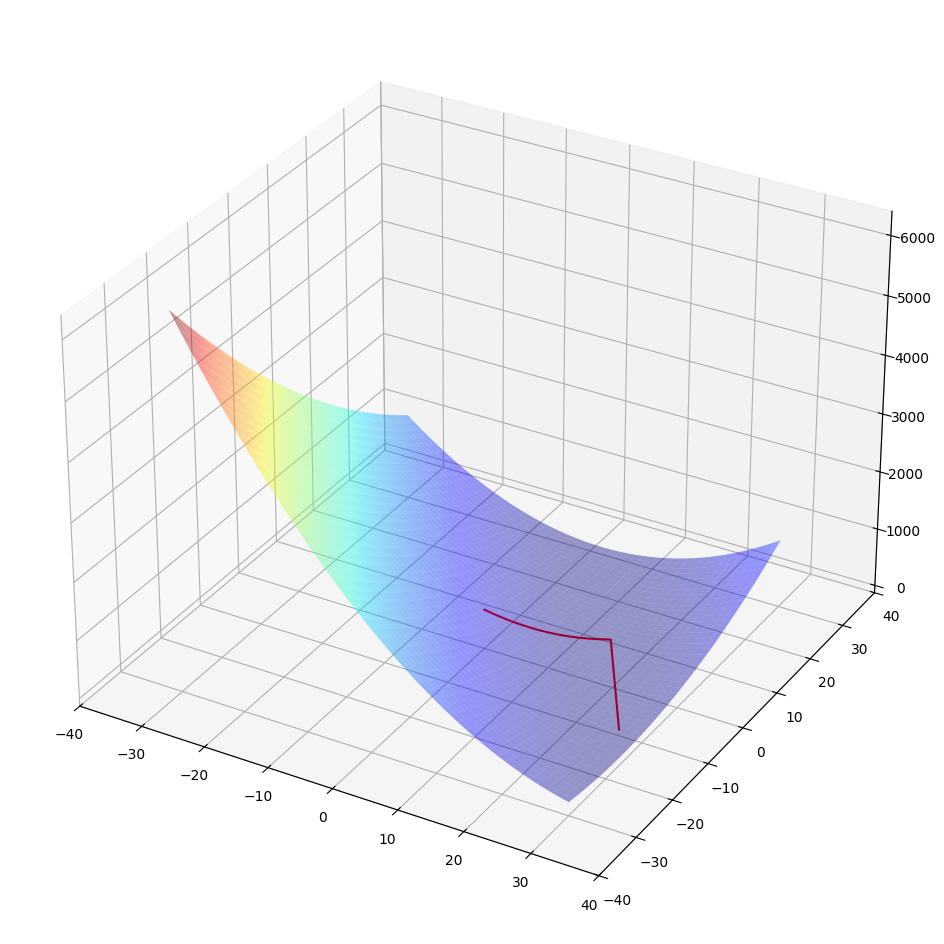

In [ ]:
# создадим последовательности из 500 значений
ww = np.linspace(-30, 30, 500)
bb = np.linspace(-30, 30, 500)

# сформируем координатную плоскость
www, bbb = np.meshgrid(ww, bb)

# а также матрицу из нулей для заполнения значениями функции J(w, b)
JJ = np.zeros([len(ww), len(bb)])

# для каждой комбинации w и b
for i in range(len(ww)):
    for j in range(len(bb)):

        # рассчитаем соответствующее прогнозное значение
        yy = www[i, j] * X + bbb[i, j]

        # и подставим его в функцию потерь (матрицу JJ)
        JJ[i, j] = 1 / (2 * len(X)) * np.sum((y - yy) ** 2)

# зададим размер графика
fig = plt.figure(figsize = (14,12))

# создадим трехмерное пространство
ax = fig.add_subplot(projection = '3d')

# построим функцию потерь
ax.plot_surface(www, bbb, JJ, alpha = 0.4, cmap = plt.cm.jet)

# а также путь алгоритма оптимизации
ax.plot(w_list, b_list, l_list, c = 'red')

# для наглядности зададим более широкие, чем график
# границы пространства
ax.set_xlim(-40, 40)
ax.set_ylim(-40, 40)

plt.show()

Мы также можем построить график изолиний («вид сверху»).

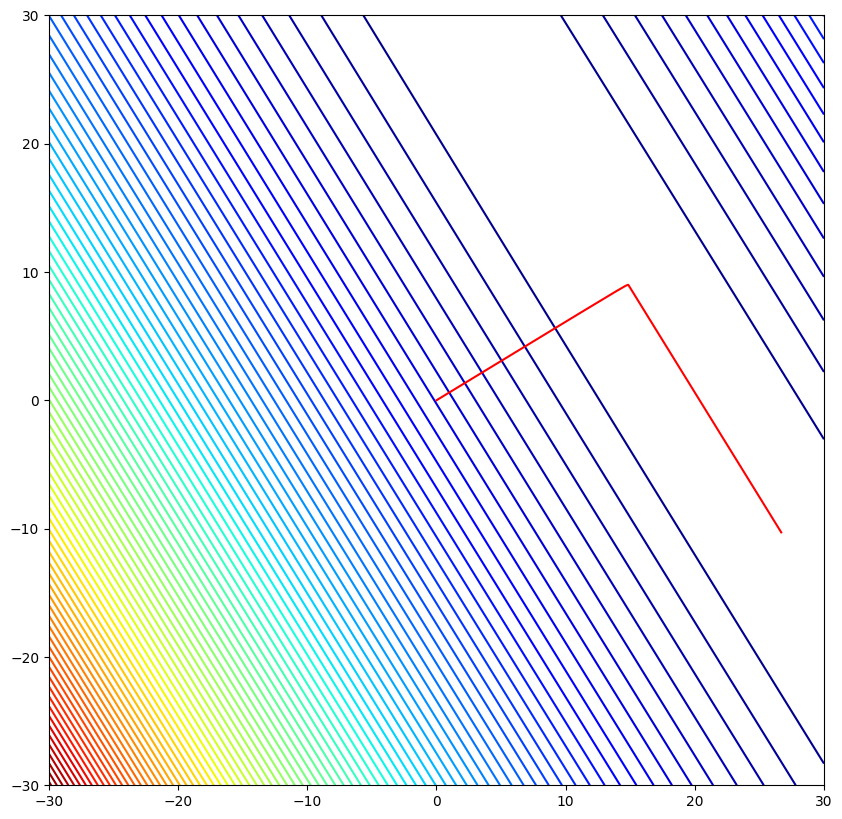

In [ ]:
# мы также можем построить график изолиний
fig, ax = plt.subplots(figsize = (10, 10))
ax.contour(www, bbb, JJ, 100, cmap = plt.cm.jet)
ax.plot(w_list, b_list, c = 'red')
plt.show()

Как мы видим, алгоритм сначала двигался в одном направлении (очевидно, так
ошибка снижалась наиболее стремительно), затем повернул на 90 градусов и
продолжил движение.
### Про выбор гиперпараметров модели
Давайте посмотрим, как поведет себя алгоритм при изменении гиперпараметров.
Вначале попробуем тот же размер шага, но уменьшим количество итераций.

In [ ]:
# попробуем тот же размер шага, но уменьшим количество итераций
w_list_t1, b_list_t1, l_list_t1 = gradient_descent(X, y, iter = 10000, learning_rate = 0.01)
w_list_t1[-1], b_list_t1[-1], l_list_t1[-1]

(np.float64(17.113947076094604),
 np.float64(5.3115083338092175),
 np.float64(0.4836593999661277))

Коэффициенты довольно сильно отличаются от найденных ранее значений.

Посмотрим на графике изолиний, где остановился наш алгоритм.

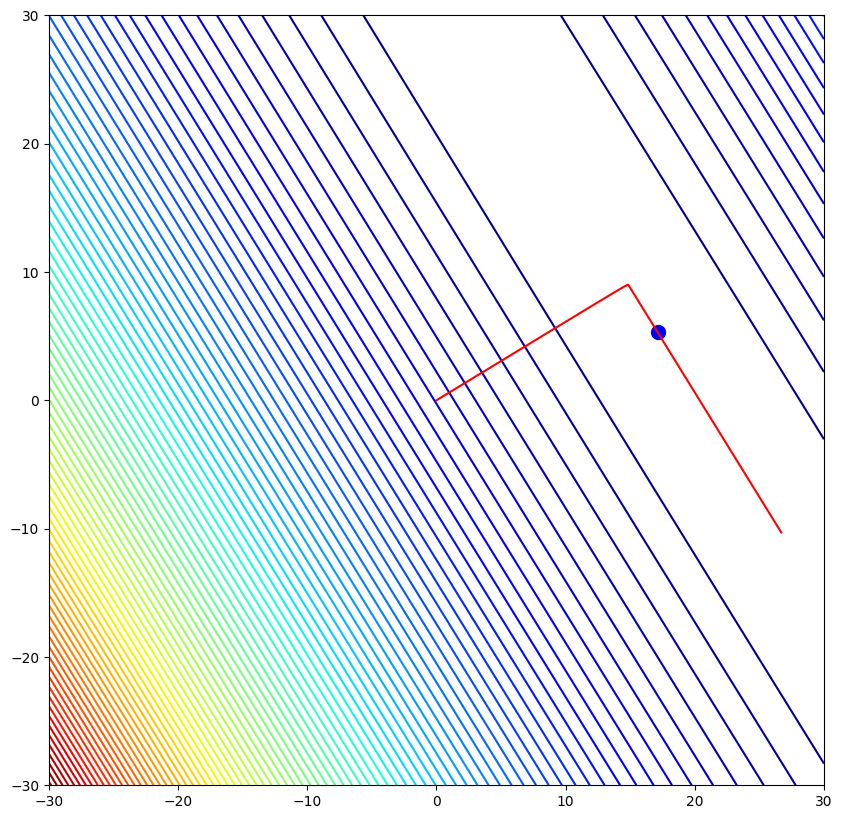

In [ ]:
# посмотрим, как мы продвинулись
fig, ax = plt.subplots(figsize = (10, 10))
ax.contour(www, bbb, JJ, 100, cmap = plt.cm.jet)
ax.plot(w_list, b_list, c = 'red')
ax.scatter(w_list_t1[-1], b_list_t1[-1], s = 100, c = 'blue')
plt.show()

Как мы видим, алгоритм немного не дошел до оптимума. Теперь давайте
попробуем уменьшить размер шага. Количество итераций вернем к прежнему
значению.

In [ ]:
# теперь вернем на место итерации, но уменьшим шаг
w_list_t2, b_list_t2, l_list_t2 = gradient_descent(X, y, iter = 200000, learning_rate = 0.0001)
w_list_t2[-1], b_list_t2[-1], l_list_t2[-1]

(np.float64(15.302448783526573),
 np.float64(8.263028645561734),
 np.float64(0.6339512457580667))

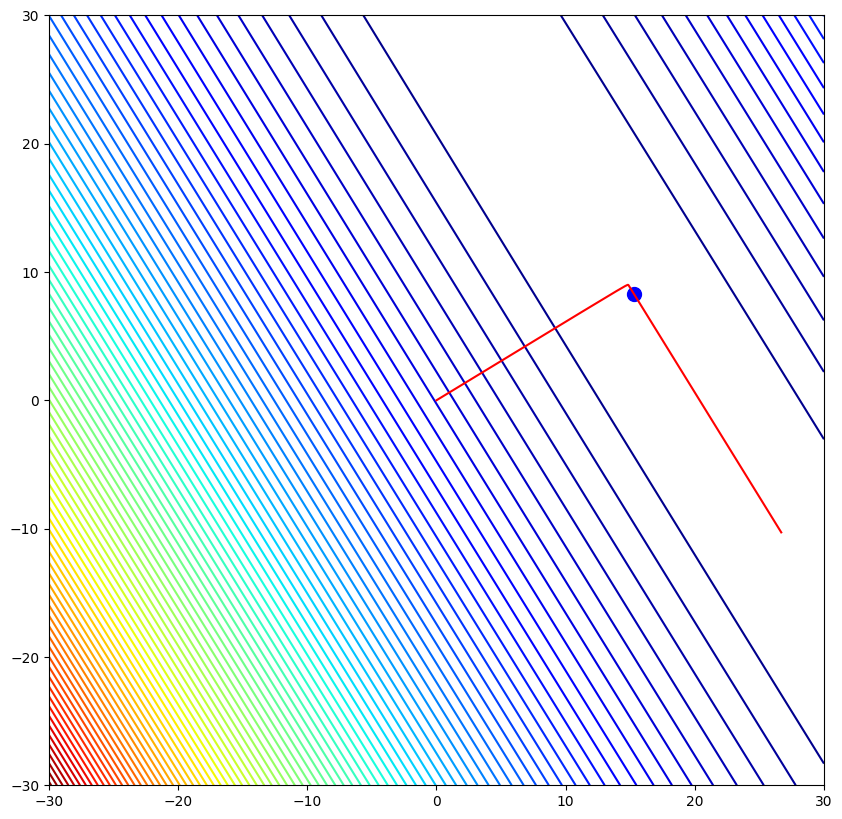

In [ ]:
# посмотрим, как мы продвинулись
fig, ax = plt.subplots(figsize = (10, 10))
ax.contour(www, bbb, JJ, 100, cmap = plt.cm.jet)
ax.plot(w_list, b_list, c = 'red')
ax.scatter(w_list_t2[-1], b_list_t2[-1], s = 100, c = 'blue')
plt.show()

В данном случае, так как мы делали слишком маленькие шаги, то продвинулись
еще меньше.

Тема выбора гиперпараметров довольно сложна и выходит за рамки сегодняшнего
занятия, однако уже на этих простых примерах видно, что один и тот же алгоритм
при разных изначальных параметрах показывает совершенно разные результаты.

## Ответы на Вопросы

**Вопрос.** Почему, если умножить функцию потерь на число, в частности на 1/2,
точка ее минимума не изменится?

**Ответ.(( Давайте посмотрим на график параболы и параболы, умноженной на 1/2.

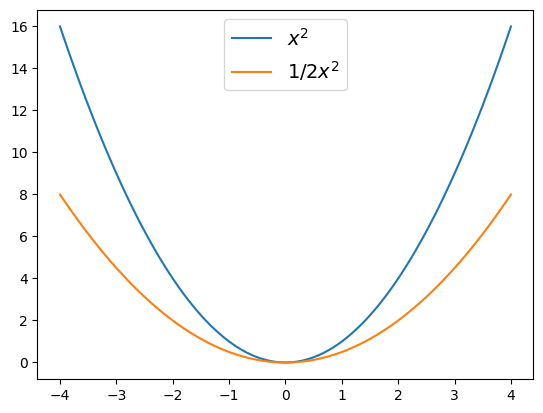

In [ ]:
# объявим функцию параболы
def f(x):
    return x ** 2

# создадим координаты x
x = np.linspace(-4, 4, 100)

# выведем графики параболы и "половины" параболы на экран
plt.plot(x, f(x), label = '$x^2$')
plt.plot(x, 1/2 * f(x), label = '$1/2x^2$')

# зададим легенду
plt.legend(loc = 'upper center', prop = {'size': 14})

# выведем результат
plt.show()

Как мы видим, точка минимума не изменилась.

При этом обратите внимание на то, что изменился наклон (значение градиента).
Эффект умножения функции потерь на число аналогичен измененению
коэффициента скорости обучения (learning rate). Чем круче наклон, тем бо́льшие по
размеру шаги мы будем делать.

**Вопрос.** Скажите, а как работает функция **np.meshgrid()**?

**Ответ.** Функция **np.meshgrid()** на входе принимает одномерные массивы и
создает двумерный массив с привычной прямоугольной (декартовой) системой
координат.

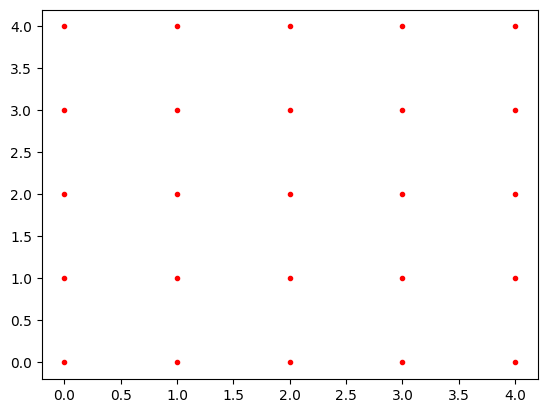

In [ ]:
# создадим простые последовательности
xvalues = np.array([0, 1, 2, 3, 4])
yvalues = np.array([0, 1, 2, 3, 4])

# сформируем координатную плоскость
xx, yy = np.meshgrid(xvalues, yvalues)

# выведем точки плоскости на графике
plt.plot(xx, yy, marker = '.', color = 'r', linestyle = 'none')
plt.show()

Обратите внимание, начало координат находится в левом нижнему углу

**Вопрос.** Функция **plt.fill_between()** заполняет пространство между двумя
функциями, но не очень понятно, какие параметры мы ей передаем.

**Ответ.** Функция **plt.fill_between(x, y1, y2 = 0)** принимает три основных
параметра: координаты по оси x, координаты по оси y (первая функция, y1) и
координаты по оси y (вторая функция, y2) и заполняет пространство между y1 и y2.
Параметр y2 не является обязательным. Если его не указывать, будет заполняться
пространство между линией y1 и осью x (то есть функцией y = 0).

Далее я привел два примера, когда параметр y2 не указывается, то есть равен 0, и когда y2 задает отличную от нуля функцию.

In [ ]:
# объявим функцию параболы
def f(x):
  return x ** 2

**Вариант 1**. Пространство между функцией параболы и осью x.

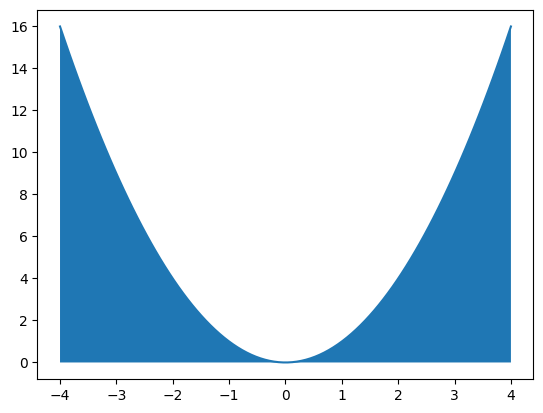

In [ ]:
# создадим пространство по оси х от -4 до 4
x = np.linspace(-4, 4, 100)

# построим график параболы
plt.plot(x, f(x))

# и заполним пространство между осью x и параболой
plt.fill_between(x, f(x))

plt.show()

**Вариант 2**. Пространство между функцией параболы и y = 16.

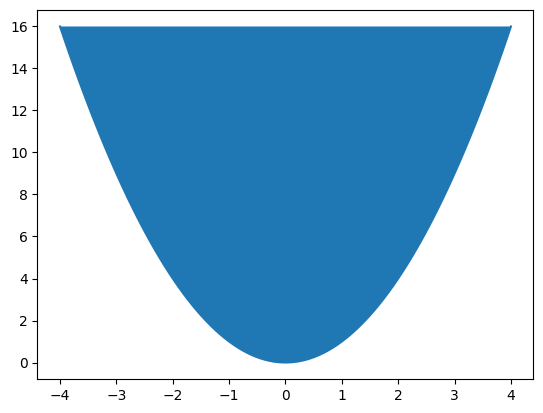

In [ ]:
# создадим пространство от -4 до 4
x = np.linspace(-4, 4, 100)

# построим график параболы
plt.plot(x, f(x))

# и заполним пространство между параболой и
# горизонтальной линией y = 16
plt.fill_between(x, f(x), 16)

plt.show()

Обратите внимание, $y = 16$ выбрана не случайно. Так как пространство по оси x, заданное np.linspace(), находится в диапазоне от $-4$ до $4$, края параболы как раз находятся в точке $y = 16,$ поскольку $(-4)^2 = 16$ и $4^2 = 16$.